# Preprocessing - Menna

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

In [ ]:
df = pd.read_csv("/content/stroke_risk_dataset_v2.csv")

In [ ]:
print(df.head())
print(df.info())


   age  gender  chest_pain  high_blood_pressure  irregular_heartbeat  \
0   22    Male           1                    0                    0   
1   52    Male           0                    1                    1   
2   63  Female           0                    1                    0   
3   41    Male           0                    0                    1   
4   53    Male           0                    0                    0   

   shortness_of_breath  fatigue_weakness  dizziness  swelling_edema  \
0                    0                 0          0               0   
1                    0                 0          0               0   
2                    0                 0          1               0   
3                    0                 1          0               0   
4                    0                 0          1               1   

   neck_jaw_pain  excessive_sweating  persistent_cough  nausea_vomiting  \
0              0                   0                 1           

 **preprocessing**


In [ ]:
# Handle Categorical Data
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [ ]:
# scaling
scaler = StandardScaler()
X = df.drop(['at_risk'], axis=1)
X_scaled = scaler.fit_transform(X)

In [ ]:
# drop unnecessary col
df = df.drop(columns=['id'], errors='ignore')

In [ ]:
print(df['at_risk'].value_counts())

at_risk
0    22113
1    12887
Name: count, dtype: int64


In [ ]:
#Handling Imbalanced Data
df_majority = df[df['at_risk'] == 0]
df_minority = df[df['at_risk'] == 1]

df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

# EDA - Nada

In [ ]:
df_balanced

,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk
0,22,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,33.3,0
3,41,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,44.5,0
5,28,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13.9,0
6,37,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,43.7,0
7,29,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16122,49,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,60.0,1
30702,52,1,0,1,0,1,1,0,1,0,0,1,0,0,1,0,0,100.0,1
26845,60,1,0,1,0,1,0,0,0,0,1,1,0,0,0,1,0,100.0,1
1520,36,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,61.3,1


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

The heatmap indicates that chest pain and high blood pressure are moderately correlated with the risk of stroke and percentage for the risk whereas age is highly correlated.

<Axes: >

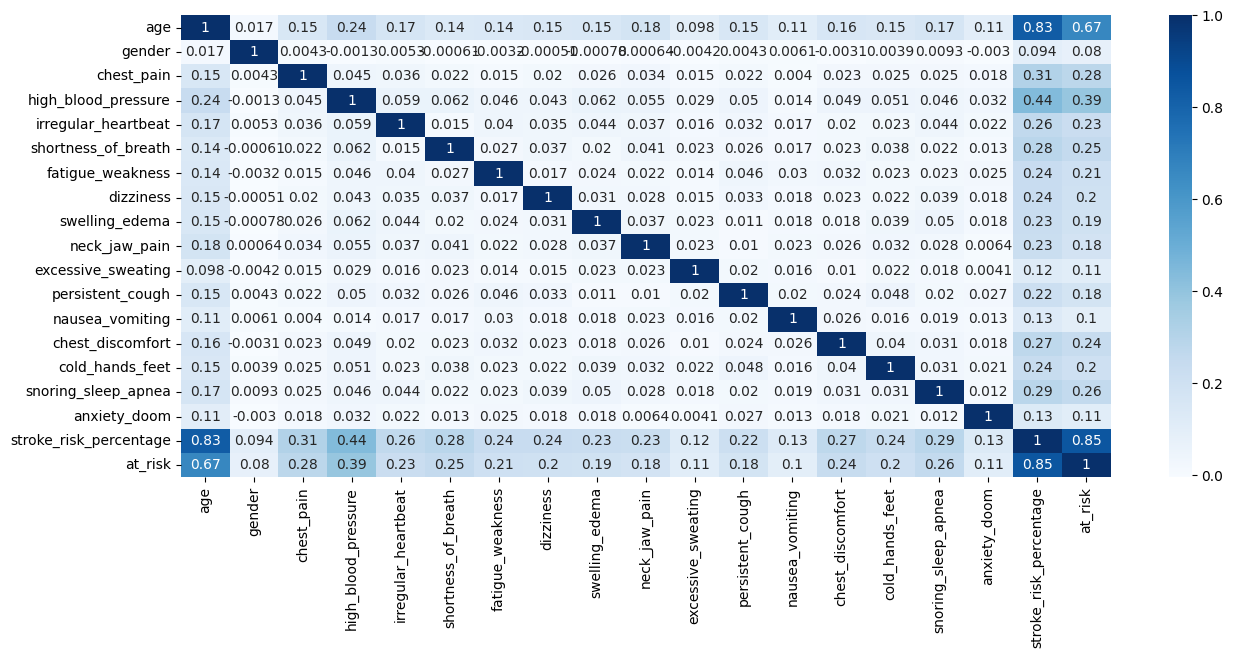

In [ ]:
correlation = df_balanced.corr()

plt.figure(figsize=[15,6])
sns.heatmap(correlation, annot=True, cmap='Blues')

Distribution of risk percentage

<Axes: xlabel='stroke_risk_percentage', ylabel='Count'>

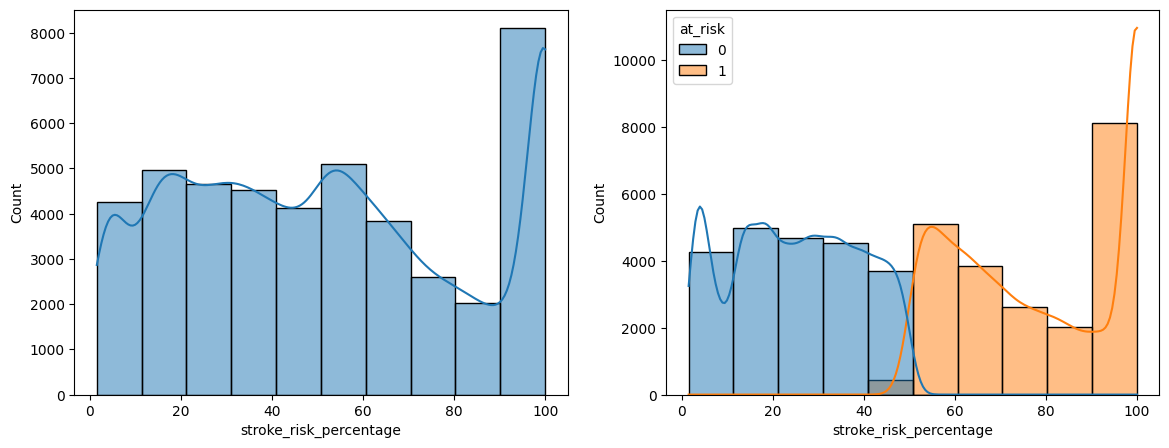

In [ ]:
plt.figure(figsize=[14,5])
plt.subplot(1,2,1)
sns.histplot(data=df_balanced, x="stroke_risk_percentage", bins=10, kde=True)

plt.subplot(1,2,2)
sns.histplot(data=df_balanced, x="stroke_risk_percentage", hue="at_risk", bins=10, kde=True)

<Axes: xlabel='stroke_risk_percentage'>

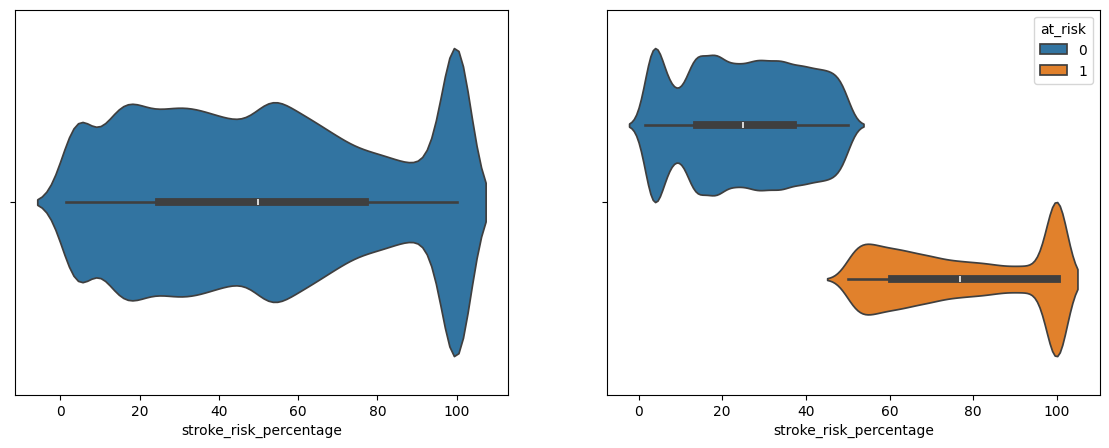

In [ ]:
plt.figure(figsize=[14,5])
plt.subplot(1,2,1)
sns.violinplot(data=df_balanced, x="stroke_risk_percentage")

plt.subplot(1,2,2)
sns.violinplot(data=df_balanced, x="stroke_risk_percentage", hue="at_risk")

Effect of age on stroke risk (There is an obvious relationship between age and stroke risk where the higher the age the higher the risk and its percentage)

<Axes: xlabel='age', ylabel='stroke_risk_percentage'>

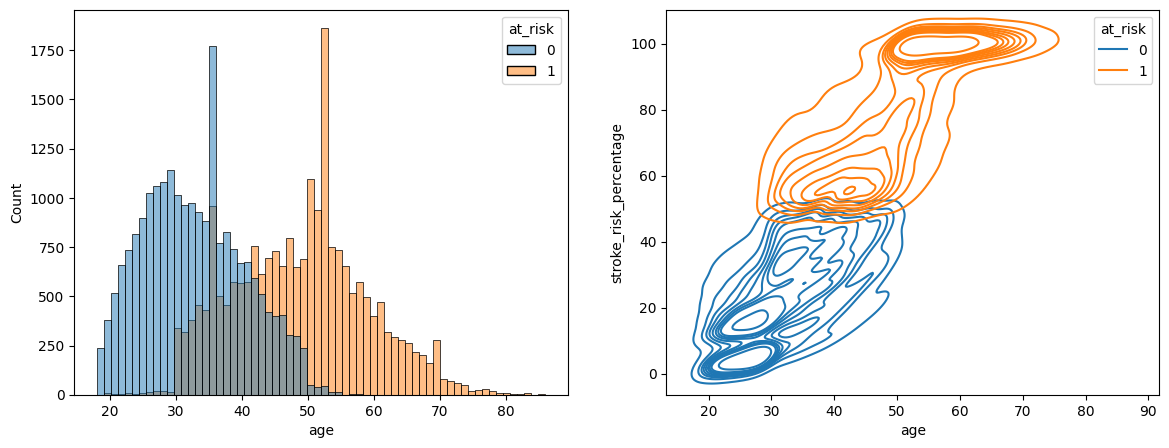

In [ ]:
# In the second graph, there is a reigon where the at risk and not at
# risk overlap which can suggest that in that reigon age and risk percentage alone can't seperate well
plt.figure(figsize=[14,5])
plt.subplot(1,2,1)
sns.histplot(data=df_balanced, x="age", hue="at_risk")

plt.subplot(1,2,2)
sns.kdeplot(data=df_balanced, x="age", y="stroke_risk_percentage", hue="at_risk")

<Axes: xlabel='at_risk', ylabel='age'>

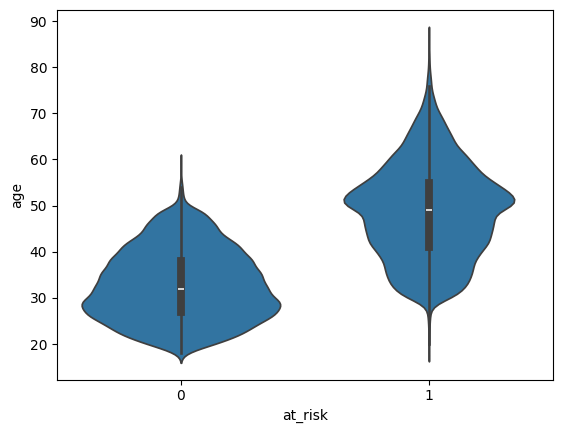

In [ ]:
sns.violinplot(data=df_balanced, x='at_risk', y='age')

Some distribution insights can be derived from the bar plots such as the frequency of the presence of a certain feature (anxiety doom is quite rare but when present it is more likely to be at risk for stroke).

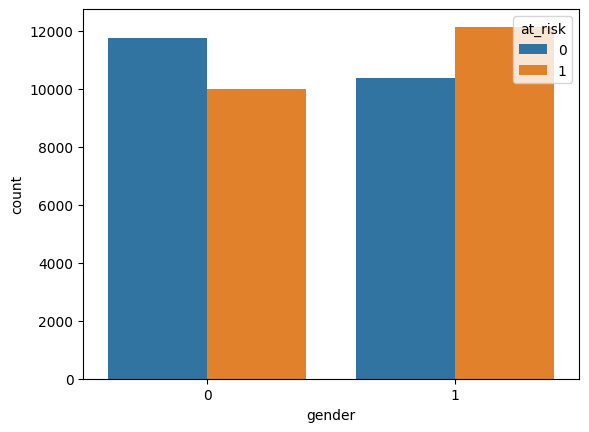

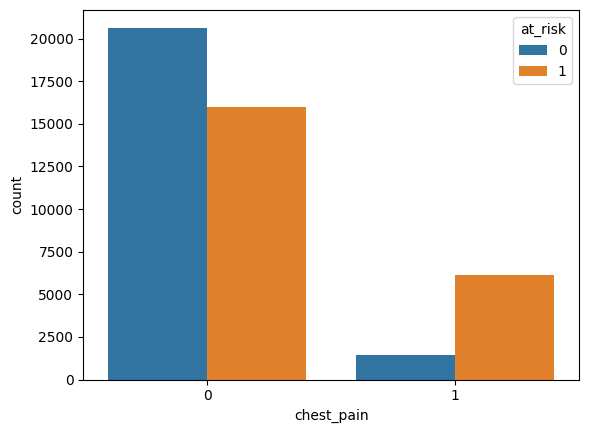

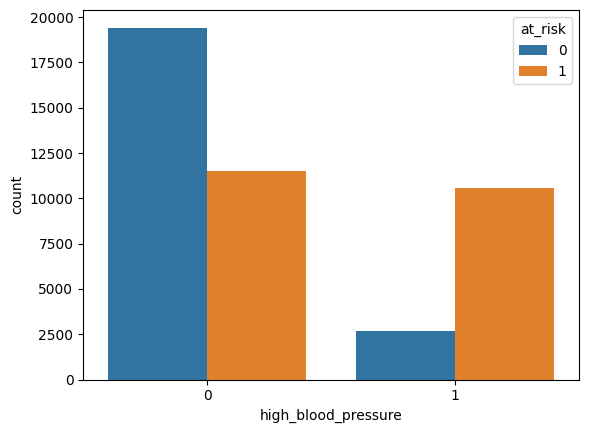

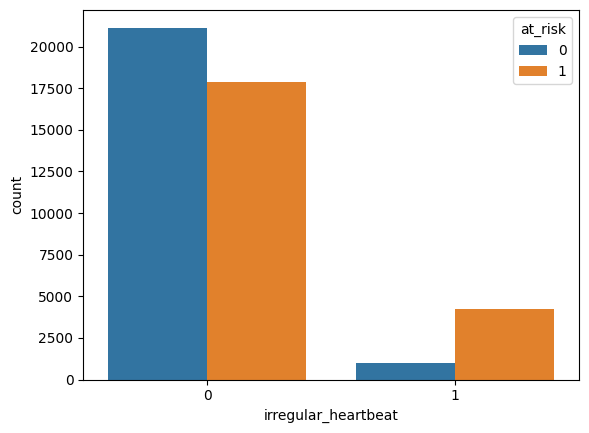

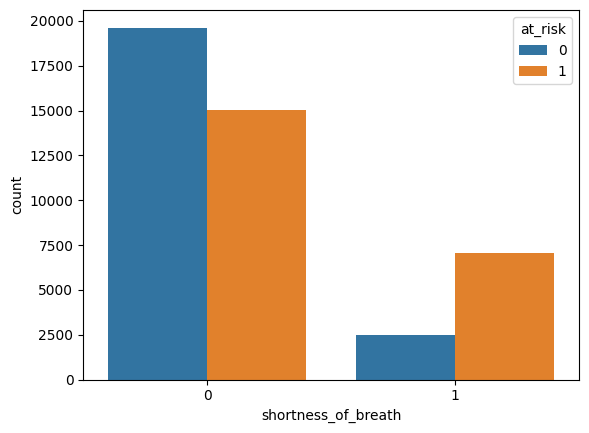

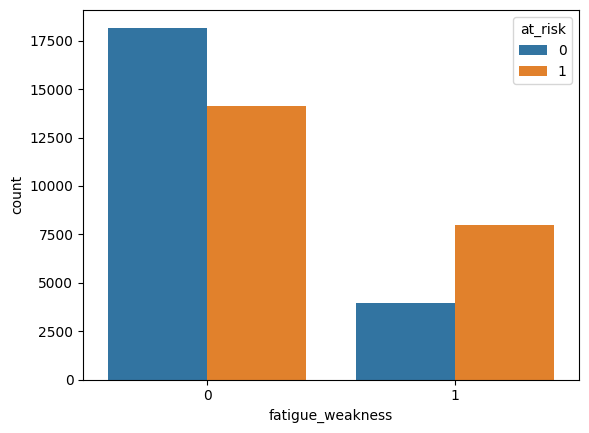

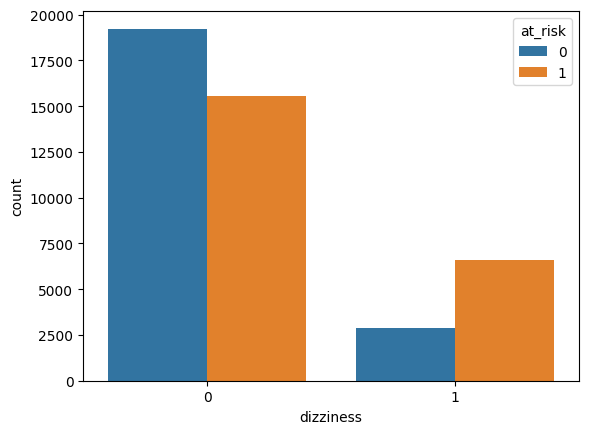

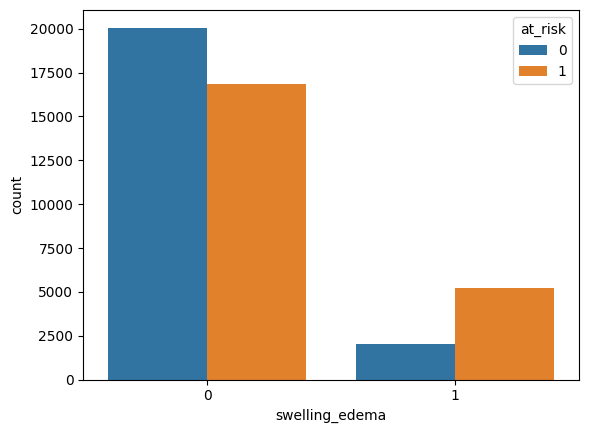

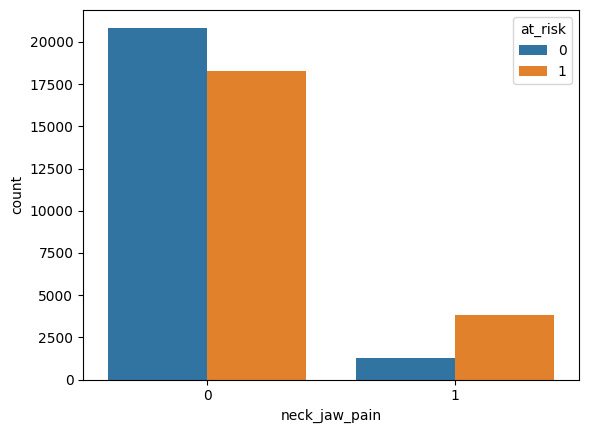

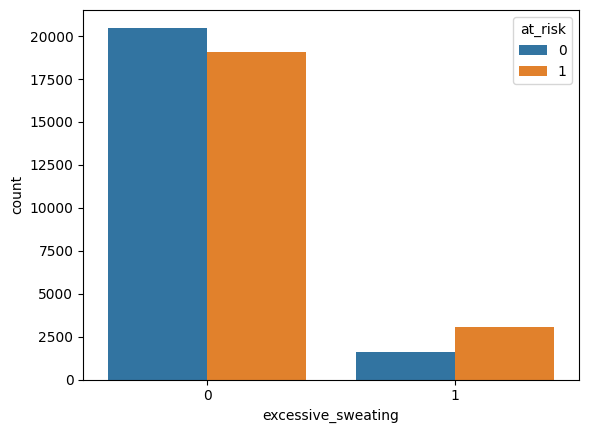

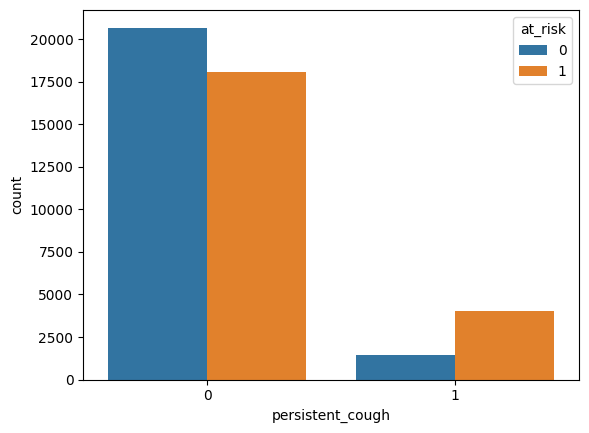

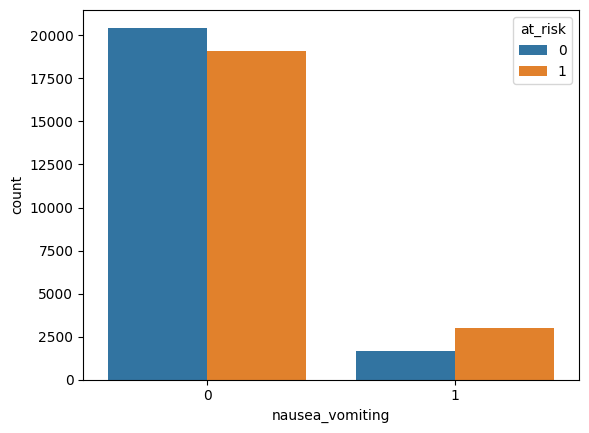

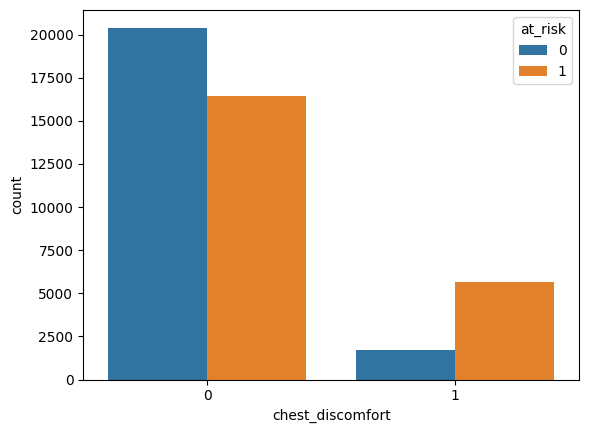

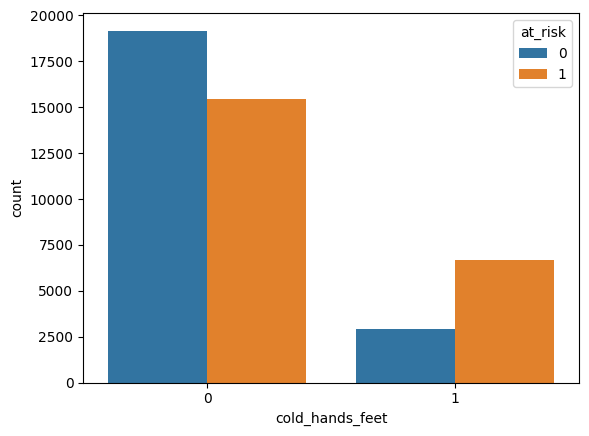

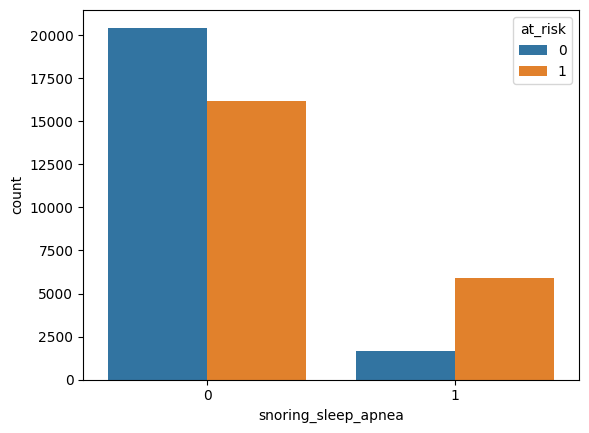

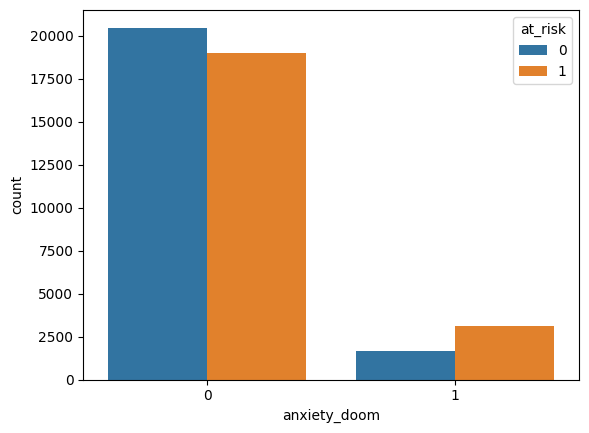

In [ ]:
for col in df_balanced:
  if col != 'age' and col != "at_risk" and col != "stroke_risk_percentage":
    plt.figure()
    sns.countplot(data=df_balanced, x=col, hue="at_risk")

Chest pain and high blood pressure

<Axes: xlabel='high_blood_pressure', ylabel='stroke_risk_percentage'>

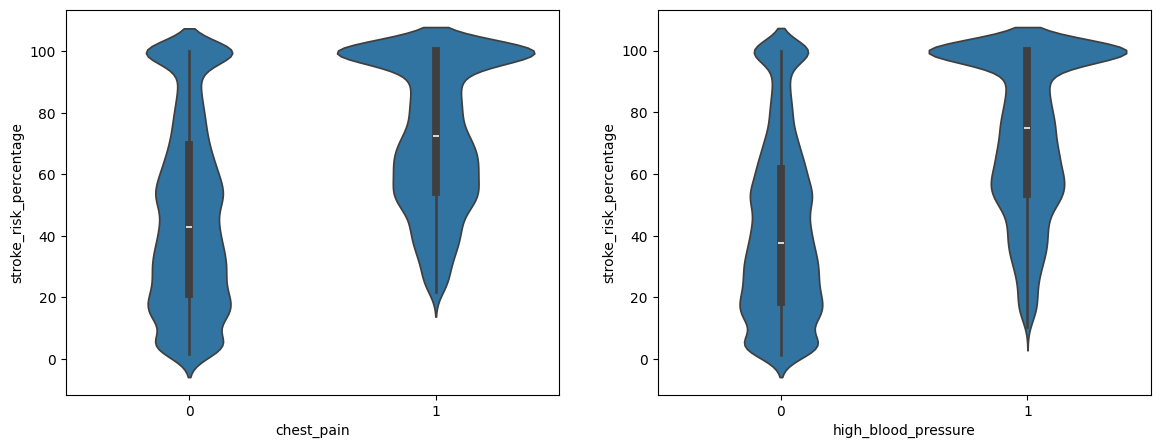

In [ ]:
plt.figure(figsize=[14,5])
plt.subplot(1,2,1)
sns.violinplot(data=df_balanced, x='chest_pain', y='stroke_risk_percentage')

plt.subplot(1,2,2)
sns.violinplot(data=df_balanced, x='high_blood_pressure', y='stroke_risk_percentage')

<Axes: xlabel='high_blood_pressure', ylabel='stroke_risk_percentage'>

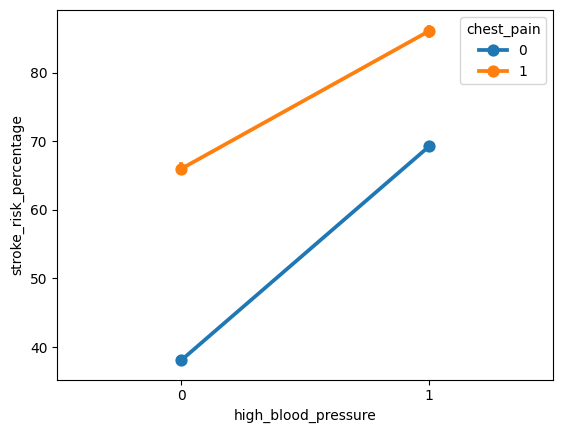

In [ ]:
#Interaction of chest pain and high blood pressure with risk
#High blood pressure but no chest pain has a higher stroke risk than having chest pain but no high blood pressure

sns.pointplot(data=df_balanced, x='high_blood_pressure', y='stroke_risk_percentage', hue='chest_pain')

# Feature Engineering / Feature Selection - Mariam

In [ ]:
symptoms = [col for col in df_balanced.columns if col not in ['age','gender','at_risk','stroke_risk_percentage']]
df_balanced['symptom_count'] = df_balanced[symptoms].sum(axis=1)

In [ ]:
df_balanced

,age,gender,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,swelling_edema,neck_jaw_pain,excessive_sweating,persistent_cough,nausea_vomiting,chest_discomfort,cold_hands_feet,snoring_sleep_apnea,anxiety_doom,stroke_risk_percentage,at_risk,symptom_count
0,22,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,33.3,0,2
3,41,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,44.5,0,2
5,28,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,13.9,0,1
6,37,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,43.7,0,2
7,29,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16122,49,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,60.0,1,3
30702,52,1,0,1,0,1,1,0,1,0,0,1,0,0,1,0,0,100.0,1,6
26845,60,1,0,1,0,1,0,0,0,0,1,1,0,0,0,1,0,100.0,1,5
1520,36,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,0,61.3,1,4


Selection

In [ ]:
df_balanced.corr()['stroke_risk_percentage'].sort_values()

,stroke_risk_percentage
gender,0.094417
excessive_sweating,0.124126
nausea_vomiting,0.126238
anxiety_doom,0.130634
persistent_cough,0.216943
neck_jaw_pain,0.226752
swelling_edema,0.231743
dizziness,0.237856
fatigue_weakness,0.238459
cold_hands_feet,0.241777


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

In [ ]:
y_balanced = df_balanced['at_risk']
X_balanced = df_balanced.drop(['at_risk', 'stroke_risk_percentage'], axis=1)

In [ ]:
# 1. Forward Feature Selection (FSF)
fsf_selector = SelectKBest(score_func=f_classif, k=12)
X_new_fsf = fsf_selector.fit_transform(X_balanced, y_balanced)

selected_fsf_features = X_balanced.columns[fsf_selector.get_support()]

# 2. Recursive Feature Elimination (RFE)
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')

rfe_selector = RFE(log_reg, n_features_to_select=12)
rfe_selector.fit(X_balanced, y_balanced)

selected_rfe_features = X_balanced.columns[rfe_selector.support_]

# Results
print("Forward Feature Selection Features:", selected_fsf_features.tolist())
print("Recursive Feature Elimination Features:", selected_rfe_features.tolist())

Forward Feature Selection Features: ['age', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'swelling_edema', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'symptom_count']
Recursive Feature Elimination Features: ['age', 'gender', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'excessive_sweating', 'nausea_vomiting', 'chest_discomfort', 'snoring_sleep_apnea', 'anxiety_doom', 'symptom_count']


In [ ]:
print("Common Features (FSF & RFE):",
      set(selected_fsf_features) & set(selected_rfe_features))

Common Features (FSF & RFE): {'snoring_sleep_apnea', 'irregular_heartbeat', 'chest_discomfort', 'shortness_of_breath', 'age', 'symptom_count', 'high_blood_pressure', 'chest_pain'}


Imformation Gain

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

mi_selector = SelectKBest(mutual_info_classif, k=10)
mi_selector.fit(X_balanced, y_balanced)

#selected features
mi_features = X_balanced.columns[mi_selector.get_support()]

#get scores for all features
mi_scores = pd.DataFrame({
    'feature': X_balanced.columns,
    'info_gain_score': mi_selector.scores_
}).sort_values('info_gain_score', ascending=False)

print(f"\nSelected {len(mi_features)} features:")
print(mi_features.tolist())

print("\nTop 10 features by Information Gain:")
print(mi_scores.head(10).to_string(index=False))


Selected 10 features:
['age', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat', 'shortness_of_breath', 'swelling_edema', 'chest_discomfort', 'cold_hands_feet', 'snoring_sleep_apnea', 'symptom_count']

Top 10 features by Information Gain:
            feature  info_gain_score
      symptom_count         0.347950
                age         0.309125
high_blood_pressure         0.082383
         chest_pain         0.042229
snoring_sleep_apnea         0.031209
shortness_of_breath         0.031056
irregular_heartbeat         0.030411
   chest_discomfort         0.030303
     swelling_edema         0.022797
    cold_hands_feet         0.022055


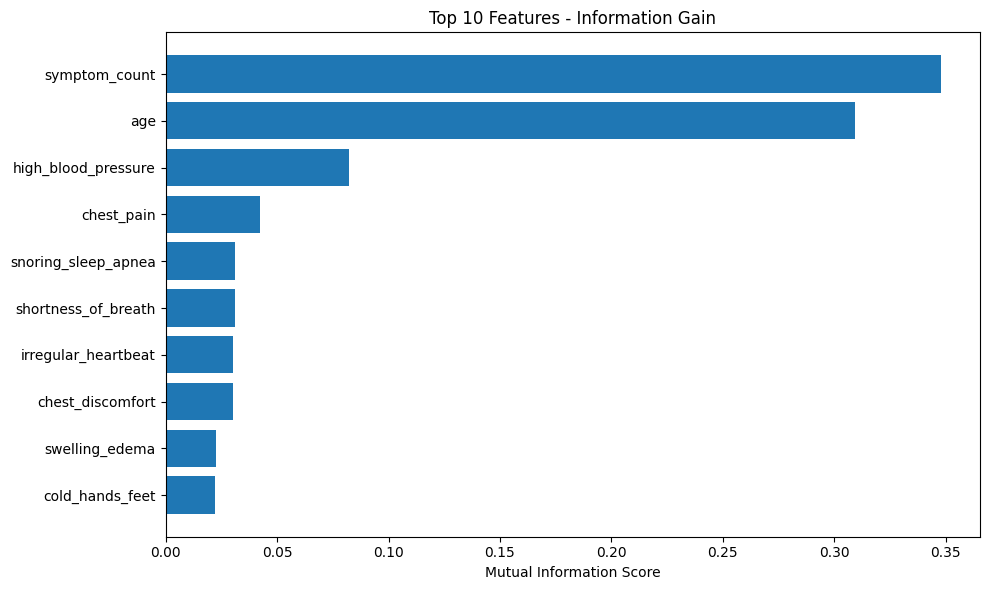

In [ ]:
# Visualize
plt.figure(figsize=(10, 6))
top10 = mi_scores.head(10)
plt.barh(range(len(top10)), top10['info_gain_score'].values)
plt.yticks(range(len(top10)), top10['feature'].values)
plt.xlabel('Mutual Information Score')
plt.title('Top 10 Features - Information Gain')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
selected = ['age', 'chest_pain', 'high_blood_pressure', 'irregular_heartbeat',
            'shortness_of_breath', 'fatigue_weakness', 'dizziness', 'neck_jaw_pain',
            'chest_discomfort', 'snoring_sleep_apnea']

data= df_balanced[selected]

In [ ]:
data = df_balanced[selected + ['stroke_risk_percentage']]

In [ ]:
data

,age,chest_pain,high_blood_pressure,irregular_heartbeat,shortness_of_breath,fatigue_weakness,dizziness,neck_jaw_pain,chest_discomfort,snoring_sleep_apnea,stroke_risk_percentage
0,22,1,0,0,0,0,0,0,0,0,33.3
3,41,0,0,1,0,1,0,0,0,0,44.5
5,28,0,0,0,0,0,0,0,0,0,13.9
6,37,1,0,0,0,0,1,0,0,0,43.7
7,29,0,0,0,0,0,0,0,0,0,6.5
...,...,...,...,...,...,...,...,...,...,...,...
16122,49,0,0,0,1,1,0,0,0,0,60.0
30702,52,0,1,0,1,1,0,0,0,0,100.0
26845,60,0,1,0,1,0,0,0,0,1,100.0
1520,36,0,1,0,0,0,1,0,0,1,61.3
